# Lab 3: Experimentación de hiperparámetros.



El objetivo de este laboratorio es experimentar con los conceptos teoricos vistos en clase. Se propone seguir la estructura de experimentos del documento. Como hemos visto durante el tema es muy importante vuestra conclusión después del experimento.

Para evaluar con cual nos quedamos después de cada experimento vamos a quedarnos con el que tenga mejor Accuracy en los datos de validación.

El dataset a utilizar consiste en imágenes de personajes de los Simpsons extraídas directamente de capítulos de la serie. Este dataset ha sido recopilado por [Alexandre Attia](http://www.alexattia.fr/) y es más complejo que el dataset de Fashion MNIST que hemos utilizado hasta ahora. Aparte de tener más clases (vamos a utilizar los 18 personajes con más imágenes), los personajes pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros personajes en pantalla (si bien el personaje a clasificar siempre aparece en la posición predominante).

El dataset de training puede ser descargado desde aquí:

[Training data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219337&authkey=AMzI92bJPx8Sd60) (~500MB)

Por otro lado, el dataset de test puede ser descargado de aquí:

[Test data](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219341&authkey=ANnjK3Uq1FhuAe8) (~10MB)

Antes de empezar la práctica, se recomienda descargar las imágenes y echarlas un vistazo.

## Carga de los datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import os
import numpy as np
import keras
import matplotlib.pyplot as plt
import glob
import zipfile

# Ruta base de los datasets en Google Drive
drive_path = '/content/drive/MyDrive/Datasets/SAA/'

# Crear carpeta de destino en el entorno de Colab
dest_path = '/content/Dataset_Simpsons/'
os.makedirs(dest_path, exist_ok=True)

# Descomprimimos los datos de entrenamiento
with zipfile.ZipFile(os.path.join(drive_path, 'simpsons_dataset.zip'), 'r') as zip_ref:
    zip_ref.extractall(dest_path)

# Descomprimimos los datos de test
with zipfile.ZipFile(os.path.join(drive_path, 'kaggle_simpson_testset.zip'), 'r') as zip_ref:
    zip_ref.extractall(dest_path)

In [3]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a estandarizar todas las imágenes a un tamaño intermedio
IMG_SIZE = 96

In [4]:
def load_train_set(dirname, map_characters, verbose=True):
    """Esta función carga los datos de training en imágenes.

    Como las imágenes tienen tamaños distintas, utilizamos la librería opencv
    para hacer un resize y adaptarlas todas a tamaño IMG_SIZE x IMG_SIZE.

    Args:
        dirname: directorio completo del que leer los datos
        map_characters: variable de mapeo entre labels y personajes
        verbose: si es True, muestra información de las imágenes cargadas

    Returns:
        X, y: X es un array con todas las imágenes cargadas con tamaño
                IMG_SIZE x IMG_SIZE
              y es un array con las labels de correspondientes a cada imagen
    """
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [5]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)


In [6]:
# Cargamos los datos. Si no estás trabajando en colab, cambia los paths por
# los de los ficheros donde hayas descargado los datos.
DATASET_TRAIN_PATH_COLAB = "/content/Dataset_Simpsons/simpsons_dataset"
DATASET_TEST_PATH_COLAB = "/content/Dataset_Simpsons/kaggle_simpson_testset"

x_train, y_train = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)
x_test, y_test = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)


Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


In [7]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(x_train))
x_train, y_train = x_train[perm], y_train[perm]

## Herramientas de visualización de resultados

In [8]:
# Definición de funciones que permitirán la visualización de las graficas de entrenamiento
def plot_acc(history, title="Model Accuracy"):
    """Imprime una gráfica mostrando la accuracy por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
    plt.show()

def plot_loss(history, title="Model Loss"):
    """Imprime una gráfica mostrando la pérdida por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
    plt.show()

def plot_compare_losses(history1, history2, name1="Red 1",
                        name2="Red 2", title="Graph title"):
    """Compara losses de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['loss'], color="green")
    plt.plot(history1.history['val_loss'], 'r--', color="green")
    plt.plot(history2.history['loss'], color="blue")
    plt.plot(history2.history['val_loss'], 'r--', color="blue")
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento ' + name1, 'Validación ' + name1,
                'Entrenamiento ' + name2, 'Validación ' + name2],
               loc='upper right')
    plt.show()

def plot_compare_accs(history1, history2, name1="Red 1",
                      name2="Red 2", title="Graph title"):
    """Compara accuracies de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['accuracy'], color="green")
    plt.plot(history1.history['val_accuracy'], 'r--', color="green")
    plt.plot(history2.history['accuracy'], color="blue")
    plt.plot(history2.history['val_accuracy'], 'r--', color="blue")
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train ' + name1, 'Val ' + name1,
                'Train ' + name2, 'Val ' + name2],
               loc='lower right')
    plt.show()



## Cosas a tener en cuenta:

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe

*   Realizar un análisis de los datos a utilizar.
* Recuerda partir los datos en training/validation para tener una buena estimación de los valores que nuestro modelo tendrá en los datos de test, así como comprobar que no estamos cayendo en overfitting. Una posible partición puede ser 80 / 20.
* Las imágenes **no están normalizadas**. Hay que normalizarlas como hemos hecho en trabajos anteriores.
* El test set del problema tiene imágenes un poco más "fáciles", por lo que es posible encontrarse con métricas en el test set bastante mejores que en el training set.
* Un error común en Keras es no instanciar un nuevo modelo cada vez que hacemos un nuevo entrenamiento. Al hacer

      *model = Sequential()*
      *model.add(lo que sea)  # Definición del modelo*
      *model.fit()*

    Si queremos entrenar un nuevo modelo o el mismo modelo otra vez, es necesario volver a inicializar el modelo con model = Sequential().
    Si olvidamos este paso y volvemos a hacer fit(), el modelo seguirá entrenando por donde se quedó en el último fit().
* Se recomienda construir una tabla con el mejor valor del acurracy y función de validación .
* Vamos a utilizar la misma arquitectura de red neuronal para todos los experimentos, que mostramos a continuación.

In [9]:
from keras import layers
from keras import models
from keras.optimizers import Adamax, RMSprop, SGD
from keras.callbacks import EarlyStopping


# Definición y construcción del modelo 1
model = models.Sequential()
model.add(layers.Conv2D(64,(2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Convolutiva-1'))
model.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPooling-1'))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu', name='Hidden-Layer-1'))
model.add(layers.Dense(64, activation='relu', name='Hidden-Layer-2'))
model.add(layers.Dense(18, activation='softmax', name='Output-Layer'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Convolutiva-1 (Conv2D)          │ (None, 96, 96, 64)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling-1 (MaxPooling2D)     │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 147456)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-Layer-1 (Dense)          │ (None, 128)            │    18,874,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-Layer-2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output-Layer (Dense)            │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,884,754 (72.04 MB)

 Trainable params: 18,884,754 (72.04 MB)

 Non-trainable params: 0 (0.00 B)

## Realización de los experimentos

### Experimento 1: Visualización y preparación del dataset

  * Visualizar algunas imagenes aleatoriamente.
  * Comprobar el número de imagenes y formato.
  * Normalizar.
  * Cualquier otra acción que consideres oportuna que enriquezca el experimento.

Primeramente vamos a visualizar aleatoriamente algunas imagenes del dataset de training junto con su etiqueta.

In [10]:
# --- Experimento 1: Visualización y preparación del dataset ---

# Información general del dataset
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'x_test shape:  {x_test.shape}')
print(f'y_test shape:  {y_test.shape}')
print(f'Tipo de dato de las imágenes: {x_train.dtype}')
print(f'Rango de valores de píxeles: [{x_train.min()}, {x_train.max()}]')
print(f'Número de clases: {len(MAP_CHARACTERS)}')


x_train shape: (18992, 96, 96, 3)
y_train shape: (18992,)
x_test shape:  (890, 96, 96, 3)
y_test shape:  (890,)
Tipo de dato de las imágenes: uint8
Rango de valores de píxeles: [0, 255]
Número de clases: 18


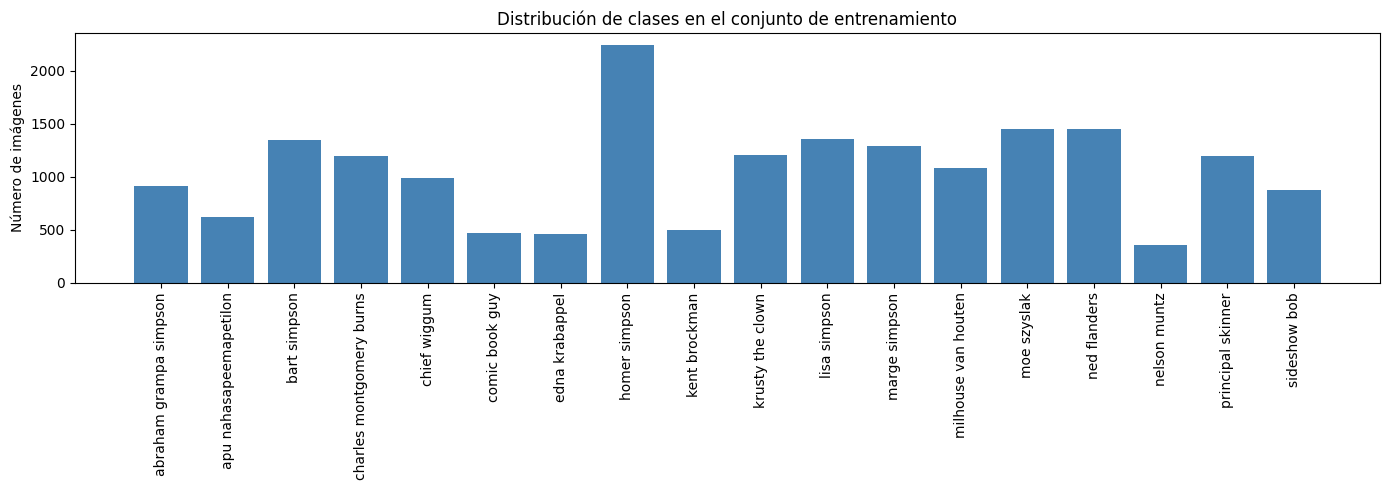

In [11]:
# Distribución de clases en entrenamiento
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(14, 5))
plt.bar([MAP_CHARACTERS[u].replace('_', ' ') for u in unique], counts, color='steelblue')
plt.xticks(rotation=90)
plt.title('Distribución de clases en el conjunto de entrenamiento')
plt.ylabel('Número de imágenes')
plt.tight_layout()
plt.show()


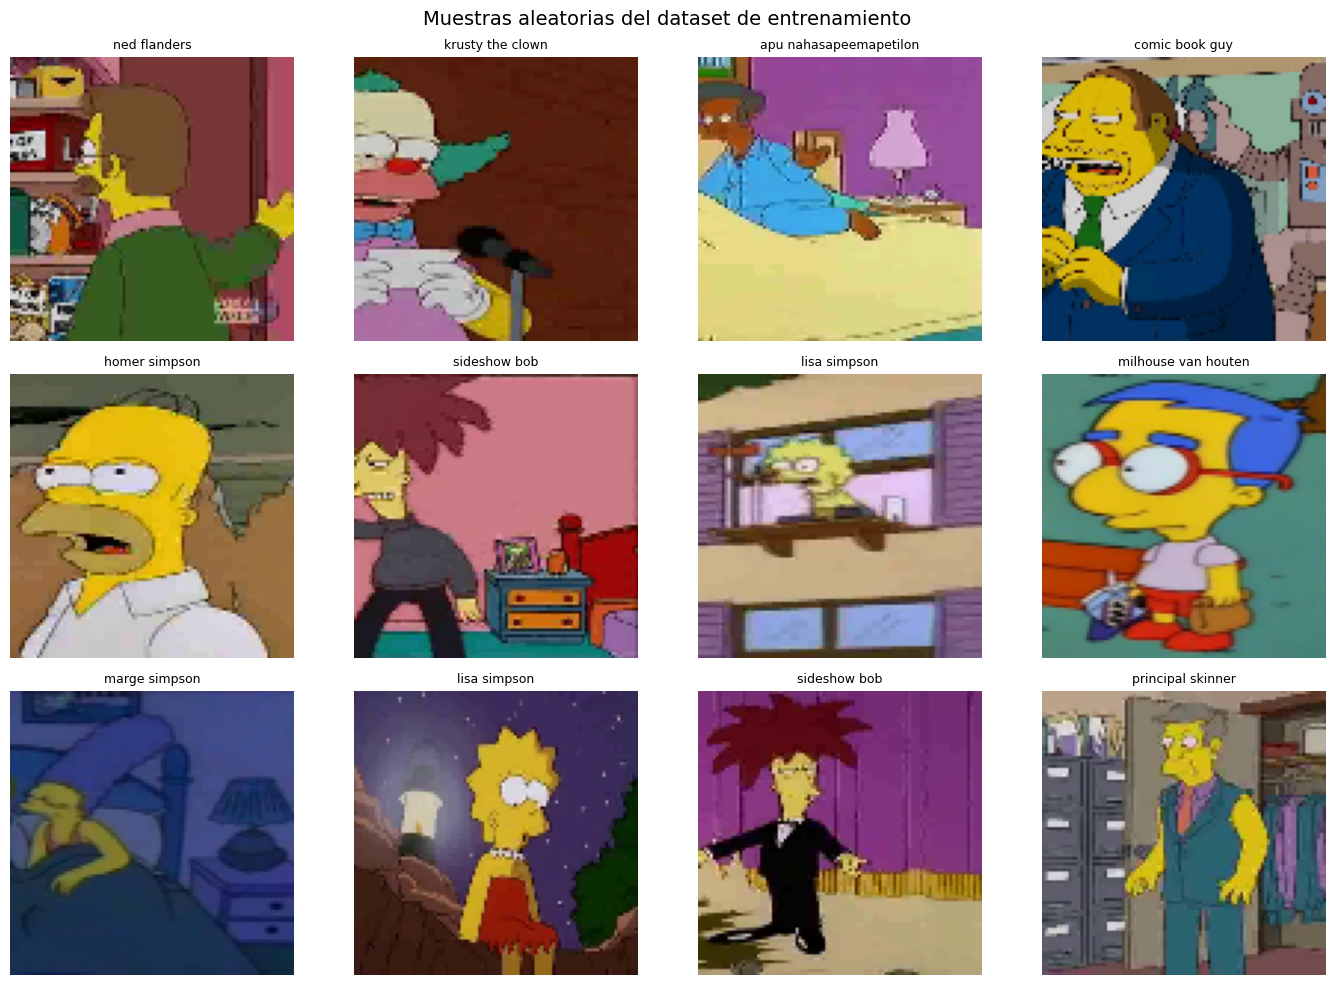

In [12]:
# Visualizar 12 imágenes aleatorias con su etiqueta
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
random_indices = np.random.choice(len(x_train), 12, replace=False)
for i, ax in enumerate(axes.flat):
    idx_img = random_indices[i]
    # OpenCV lee en BGR, convertimos a RGB para visualizar
    img_rgb = cv2.cvtColor(x_train[idx_img], cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(MAP_CHARACTERS[y_train[idx_img]].replace('_', ' '), fontsize=9)
    ax.axis('off')
plt.suptitle('Muestras aleatorias del dataset de entrenamiento', fontsize=14)
plt.tight_layout()
plt.show()


In [13]:
# Normalización de los datos (dividir entre 255 para obtener rango [0, 1])
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print(f'Rango de valores después de normalizar: [{x_train_norm.min()}, {x_train_norm.max()}]')
print(f'Tipo de dato tras normalizar: {x_train_norm.dtype}')


Rango de valores después de normalizar: [0.0, 1.0]
Tipo de dato tras normalizar: float32


**Conclusión Experimento 1:** El dataset contiene imágenes de 18 personajes de los Simpsons redimensionadas a 64×64 píxeles con 3 canales (BGR). Se observa un desbalanceo entre clases (algunos personajes tienen más imágenes que otros). Las imágenes se han normalizado al rango [0, 1] dividiendo entre 255, lo cual facilita la convergencia del entrenamiento.

### Experimento 2:  Relu vs Tangente hiperbólica

Para la realización de este experimento tiene que utilizar los siguientes hiperparámetros:


*   Optimizer: SGD
*   Loss: sparse_categorical_crossentropy
*   Metrics: accuracy
*   EarlyStopping
      *   monitor=val_loss
      *   patience = 2
      *   verbose=1
*   Batch_size: 32




Construcción del modelo Relu.

In [14]:
# --- Experimento 2: ReLU vs Tanh ---

# Modelo con activación ReLU
model_relu = models.Sequential()
model_relu.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96,96,3), padding='same', name='Conv-1'))
model_relu.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_relu.add(layers.Flatten())
model_relu.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_relu.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_relu.add(layers.Dense(18, activation='softmax', name='Output'))

model_relu.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_relu = model_relu.fit(x_train_norm, y_train, batch_size=32,
                              epochs=20, validation_split=0.2,
                              callbacks=[early_stop])
print('Mejor val_accuracy ReLU:', max(history_relu.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.1971 - loss: 2.5929 - val_accuracy: 0.2774 - val_loss: 2.3350
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3585 - loss: 2.1396 - val_accuracy: 0.3796 - val_loss: 2.0594
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4562 - loss: 1.8360 - val_accuracy: 0.4691 - val_loss: 1.8099
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5306 - loss: 1.5838 - val_accuracy: 0.5241 - val_loss: 1.6128
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5872 - loss: 1.3958 - val_accuracy: 0.5467 - val_loss: 1.5482
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6402 - loss: 1.2259 - val_accuracy: 0.5944 - val_loss: 1.4044
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6863 - loss: 1.0662 - val_accuracy: 0.6007 - val_loss: 1.3836
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7326 - loss: 0.9175 - val_acc

In [15]:
# Modelo con activación Tanh
model_tanh = models.Sequential()
model_tanh.add(layers.Conv2D(64, (2,2), activation='tanh', input_shape=(96,96,3), padding='same', name='Conv-1'))
model_tanh.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_tanh.add(layers.Flatten())
model_tanh.add(layers.Dense(128, activation='tanh', name='Hidden-1'))
model_tanh.add(layers.Dense(64, activation='tanh', name='Hidden-2'))
model_tanh.add(layers.Dense(18, activation='softmax', name='Output'))

model_tanh.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_tanh = model_tanh.fit(x_train_norm, y_train, batch_size=32,
                              epochs=20, validation_split=0.2,
                              callbacks=[early_stop])
print('Mejor val_accuracy Tanh:', max(history_tanh.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.3189 - loss: 2.2708 - val_accuracy: 0.3975 - val_loss: 2.0206
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4690 - loss: 1.8318 - val_accuracy: 0.4638 - val_loss: 1.8531
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5325 - loss: 1.6338 - val_accuracy: 0.4835 - val_loss: 1.7480
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5816 - loss: 1.4662 - val_accuracy: 0.5154 - val_loss: 1.6641
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6368 - loss: 1.3099 - val_accuracy: 0.5183 - val_loss: 1.6365
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6852 - loss: 1.1535 - val_accuracy: 0.5407 - val_loss: 1.5870
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7350 - loss: 1.0033 - val_accuracy: 0.5675 - val_loss: 1.5040
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7785 - loss: 0.8573 - val_acc

/tmp/ipykernel_2543/1194942400.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


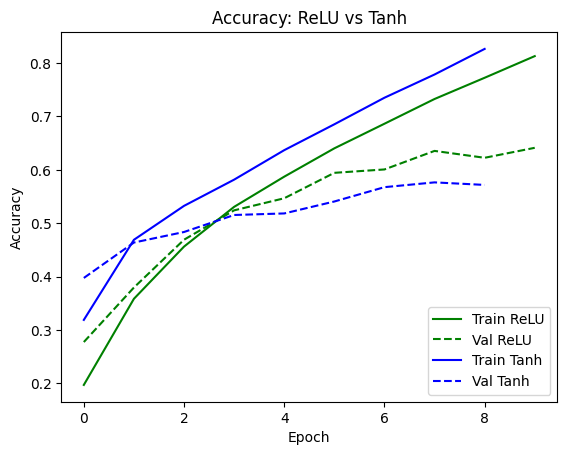

/tmp/ipykernel_2543/1194942400.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_loss'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_loss'], 'r--', color="blue")


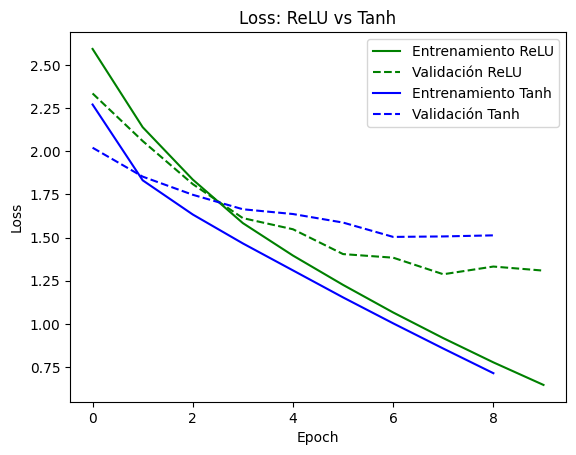

Mejor val_accuracy ReLU: 0.6412
Mejor val_accuracy Tanh: 0.5765


In [16]:
# Comparación ReLU vs Tanh
plot_compare_accs(history_relu, history_tanh, name1='ReLU', name2='Tanh', title='Accuracy: ReLU vs Tanh')
plot_compare_losses(history_relu, history_tanh, name1='ReLU', name2='Tanh', title='Loss: ReLU vs Tanh')

print(f'Mejor val_accuracy ReLU: {max(history_relu.history["val_accuracy"]):.4f}')
print(f'Mejor val_accuracy Tanh: {max(history_tanh.history["val_accuracy"]):.4f}')


**Conclusión Experimento 2:** Se comparan las funciones de activación ReLU y Tanh. Generalmente ReLU converge más rápido y evita el problema del gradiente desvaneciente, por lo que suele obtener mejor accuracy de validación. Nos quedamos con la función de activación que mejor val_accuracy obtenga para los siguientes experimentos.

### Experimento 3: Zero vs Glorot uniform



In [17]:
# --- Experimento 3: Zeros vs Glorot Uniform ---

# Modelo con inicialización Zeros
model_zeros = models.Sequential()
model_zeros.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3),
                              padding='same', kernel_initializer='zeros', name='Conv-1'))
model_zeros.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_zeros.add(layers.Flatten())
model_zeros.add(layers.Dense(128, activation='relu', kernel_initializer='zeros', name='Hidden-1'))
model_zeros.add(layers.Dense(64, activation='relu', kernel_initializer='zeros', name='Hidden-2'))
model_zeros.add(layers.Dense(18, activation='softmax', kernel_initializer='zeros', name='Output'))

model_zeros.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_zeros = model_zeros.fit(x_train_norm, y_train, batch_size=32,
                                epochs=20, validation_split=0.2,
                                callbacks=[early_stop])
print('Mejor val_accuracy Zeros:', max(history_zeros.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.1171 - loss: 2.8697 - val_accuracy: 0.1213 - val_loss: 2.8521
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1175 - loss: 2.8402 - val_accuracy: 0.1213 - val_loss: 2.8299
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1175 - loss: 2.8230 - val_accuracy: 0.1213 - val_loss: 2.8171
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1175 - loss: 2.8130 - val_accuracy: 0.1213 - val_loss: 2.8096
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1175 - loss: 2.8069 - val_accuracy: 0.1213 - val_loss: 2.8051
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1175 - loss: 2.8031 - val_accuracy: 0.1213 - val_loss: 2.8023
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1175 - loss: 2.8006 - val_accuracy: 0.1213 - val_loss: 2.8005
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1175 - loss: 2.7989 - val_accu

In [18]:
# Modelo con inicialización Glorot Uniform (por defecto en Keras)
model_glorot = models.Sequential()
model_glorot.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3),
                               padding='same', kernel_initializer='glorot_uniform', name='Conv-1'))
model_glorot.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_glorot.add(layers.Flatten())
model_glorot.add(layers.Dense(128, activation='relu', kernel_initializer='glorot_uniform', name='Hidden-1'))
model_glorot.add(layers.Dense(64, activation='relu', kernel_initializer='glorot_uniform', name='Hidden-2'))
model_glorot.add(layers.Dense(18, activation='softmax', kernel_initializer='glorot_uniform', name='Output'))

model_glorot.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_glorot = model_glorot.fit(x_train_norm, y_train, batch_size=32,
                                  epochs=20, validation_split=0.2,
                                  callbacks=[early_stop])
print('Mejor val_accuracy Glorot Uniform:', max(history_glorot.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.1659 - loss: 2.6574 - val_accuracy: 0.2301 - val_loss: 2.4073
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3205 - loss: 2.2199 - val_accuracy: 0.3438 - val_loss: 2.1517
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4259 - loss: 1.9280 - val_accuracy: 0.4446 - val_loss: 1.8638
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5002 - loss: 1.6948 - val_accuracy: 0.4957 - val_loss: 1.6909
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5645 - loss: 1.4882 - val_accuracy: 0.5438 - val_loss: 1.5574
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6140 - loss: 1.3158 - val_accuracy: 0.5752 - val_loss: 1.4570
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6603 - loss: 1.1611 - val_accuracy: 0.6012 - val_loss: 1.3624
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6951 - loss: 1.0168 - val_accu

/tmp/ipykernel_2543/1194942400.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


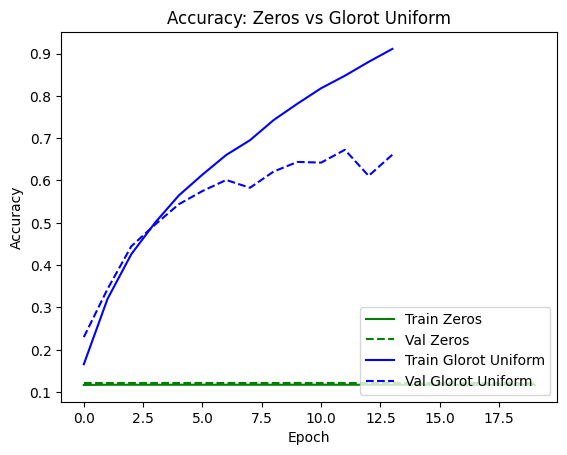

/tmp/ipykernel_2543/1194942400.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_loss'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_loss'], 'r--', color="blue")


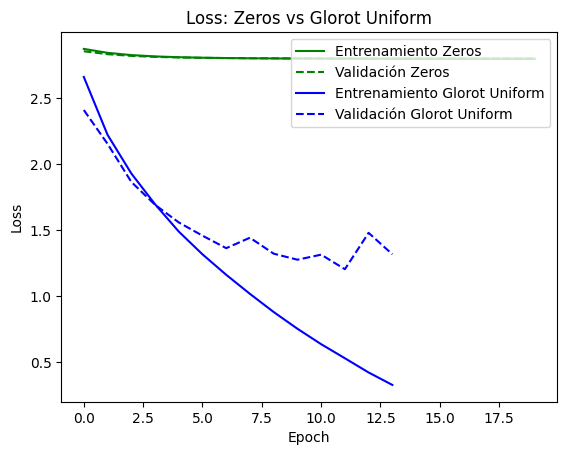

Mejor val_accuracy Zeros:         0.1213
Mejor val_accuracy Glorot Uniform: 0.6725


In [19]:
# Comparación Zeros vs Glorot Uniform
plot_compare_accs(history_zeros, history_glorot, name1='Zeros', name2='Glorot Uniform',
                  title='Accuracy: Zeros vs Glorot Uniform')
plot_compare_losses(history_zeros, history_glorot, name1='Zeros', name2='Glorot Uniform',
                    title='Loss: Zeros vs Glorot Uniform')

print(f'Mejor val_accuracy Zeros:         {max(history_zeros.history["val_accuracy"]):.4f}')
print(f'Mejor val_accuracy Glorot Uniform: {max(history_glorot.history["val_accuracy"]):.4f}')


**Conclusión Experimento 3:** Inicializar los pesos a cero provoca que todas las neuronas computen lo mismo (problema de simetría), impidiendo el aprendizaje. Glorot Uniform rompe esta simetría distribuyendo los pesos de forma adecuada, lo que permite una convergencia efectiva. Nos quedamos con Glorot Uniform.

### Experimento 4 - Aleatoria Normal vs Glorot uniform  


In [20]:
# --- Experimento 4: Random Normal vs Glorot Uniform ---

# Modelo con inicialización Random Normal
model_rnorm = models.Sequential()
model_rnorm.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3),
                              padding='same', kernel_initializer='random_normal', name='Conv-1'))
model_rnorm.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_rnorm.add(layers.Flatten())
model_rnorm.add(layers.Dense(128, activation='relu', kernel_initializer='random_normal', name='Hidden-1'))
model_rnorm.add(layers.Dense(64, activation='relu', kernel_initializer='random_normal', name='Hidden-2'))
model_rnorm.add(layers.Dense(18, activation='softmax', kernel_initializer='random_normal', name='Output'))

model_rnorm.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_rnorm = model_rnorm.fit(x_train_norm, y_train, batch_size=32,
                                epochs=20, validation_split=0.2,
                                callbacks=[early_stop])
print('Mejor val_accuracy Random Normal:', max(history_rnorm.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.1261 - loss: 2.7569 - val_accuracy: 0.1661 - val_loss: 2.6583
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.2297 - loss: 2.4853 - val_accuracy: 0.2795 - val_loss: 2.3576
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3104 - loss: 2.2528 - val_accuracy: 0.3098 - val_loss: 2.3197
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3673 - loss: 2.1027 - val_accuracy: 0.3767 - val_loss: 2.1048
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4064 - loss: 1.9726 - val_accuracy: 0.3859 - val_loss: 2.0245
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4378 - loss: 1.8552 - val_accuracy: 0.4317 - val_loss: 1.9051
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4713 - loss: 1.7495 - val_accuracy: 0.4585 - val_loss: 1.8139
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5057 - loss: 1.6428 - val_acc

In [21]:
# Modelo Glorot Uniform (reutilizamos la misma arquitectura)
model_glorot2 = models.Sequential()
model_glorot2.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3),
                                padding='same', kernel_initializer='glorot_uniform', name='Conv-1'))
model_glorot2.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_glorot2.add(layers.Flatten())
model_glorot2.add(layers.Dense(128, activation='relu', kernel_initializer='glorot_uniform', name='Hidden-1'))
model_glorot2.add(layers.Dense(64, activation='relu', kernel_initializer='glorot_uniform', name='Hidden-2'))
model_glorot2.add(layers.Dense(18, activation='softmax', kernel_initializer='glorot_uniform', name='Output'))

model_glorot2.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_glorot2 = model_glorot2.fit(x_train_norm, y_train, batch_size=32,
                                    epochs=20, validation_split=0.2,
                                    callbacks=[early_stop])
print('Mejor val_accuracy Glorot Uniform:', max(history_glorot2.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.2038 - loss: 2.5565 - val_accuracy: 0.3301 - val_loss: 2.2516
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3845 - loss: 2.0699 - val_accuracy: 0.3959 - val_loss: 2.0304
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4800 - loss: 1.7598 - val_accuracy: 0.4793 - val_loss: 1.7402
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5485 - loss: 1.5282 - val_accuracy: 0.5351 - val_loss: 1.5952
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6073 - loss: 1.3376 - val_accuracy: 0.5557 - val_loss: 1.5569
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6602 - loss: 1.1621 - val_accuracy: 0.5986 - val_loss: 1.3902
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7064 - loss: 1.0017 - val_accuracy: 0.6288 - val_loss: 1.2819
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7556 - loss: 0.8513 - val_acc

/tmp/ipykernel_2543/1194942400.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


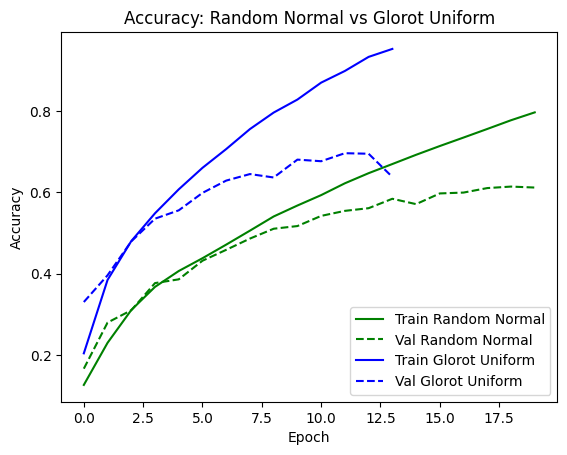

/tmp/ipykernel_2543/1194942400.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_loss'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_loss'], 'r--', color="blue")


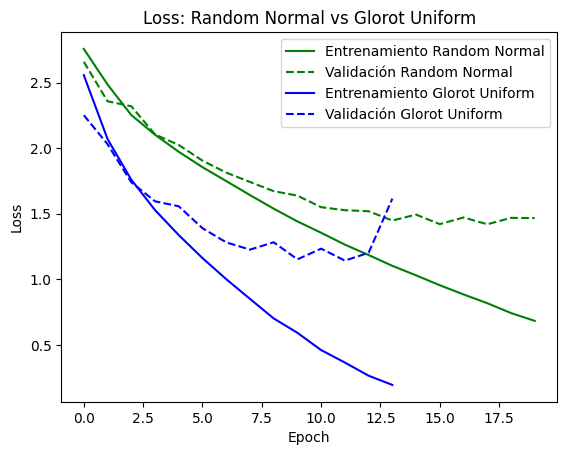

Mejor val_accuracy Random Normal:  0.6141
Mejor val_accuracy Glorot Uniform: 0.6962


In [22]:
# Comparación Random Normal vs Glorot Uniform
plot_compare_accs(history_rnorm, history_glorot2, name1='Random Normal', name2='Glorot Uniform',
                  title='Accuracy: Random Normal vs Glorot Uniform')
plot_compare_losses(history_rnorm, history_glorot2, name1='Random Normal', name2='Glorot Uniform',
                    title='Loss: Random Normal vs Glorot Uniform')

print(f'Mejor val_accuracy Random Normal:  {max(history_rnorm.history["val_accuracy"]):.4f}')
print(f'Mejor val_accuracy Glorot Uniform: {max(history_glorot2.history["val_accuracy"]):.4f}')


**Conclusión Experimento 4:** Glorot Uniform está diseñado para mantener la varianza de las activaciones a lo largo de las capas, lo que suele dar lugar a un entrenamiento más estable y una mejor convergencia que una inicialización Random Normal genérica (media 0, std 0.05). Nos quedamos con Glorot Uniform.

### Experimento 5 - SGD vs RMSprop




In [23]:
# --- Experimento 5: SGD vs RMSprop ---

# Modelo con SGD
model_sgd = models.Sequential()
model_sgd.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_sgd.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_sgd.add(layers.Flatten())
model_sgd.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_sgd.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_sgd.add(layers.Dense(18, activation='softmax', name='Output'))

model_sgd.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_sgd = model_sgd.fit(x_train_norm, y_train, batch_size=32,
                            epochs=20, validation_split=0.2,
                            callbacks=[early_stop])
print('Mejor val_accuracy SGD:', max(history_sgd.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.2206 - loss: 2.5100 - val_accuracy: 0.2903 - val_loss: 2.3148
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3914 - loss: 2.0470 - val_accuracy: 0.4220 - val_loss: 1.9527
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4935 - loss: 1.7370 - val_accuracy: 0.4709 - val_loss: 1.7494
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5585 - loss: 1.5004 - val_accuracy: 0.5307 - val_loss: 1.6054
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6160 - loss: 1.3157 - val_accuracy: 0.5720 - val_loss: 1.4559
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6655 - loss: 1.1413 - val_accuracy: 0.6020 - val_loss: 1.3783
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7153 - loss: 0.9803 - val_accuracy: 0.6160 - val_loss: 1.3483
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7600 - loss: 0.8290 - val_acc

In [24]:
# Modelo con RMSprop
model_rmsprop = models.Sequential()
model_rmsprop.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_rmsprop.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_rmsprop.add(layers.Flatten())
model_rmsprop.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_rmsprop.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_rmsprop.add(layers.Dense(18, activation='softmax', name='Output'))

model_rmsprop.compile(optimizer=RMSprop(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_rmsprop = model_rmsprop.fit(x_train_norm, y_train, batch_size=32,
                                    epochs=20, validation_split=0.2,
                                    callbacks=[early_stop])
print('Mejor val_accuracy RMSprop:', max(history_rmsprop.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.3895 - loss: 2.2105 - val_accuracy: 0.4922 - val_loss: 1.6793
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6420 - loss: 1.2222 - val_accuracy: 0.6204 - val_loss: 1.2872
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7785 - loss: 0.7481 - val_accuracy: 0.6428 - val_loss: 1.2754
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8799 - loss: 0.4120 - val_accuracy: 0.6386 - val_loss: 1.4603
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9396 - loss: 0.2058 - val_accuracy: 0.6733 - val_loss: 1.4577
Epoch 5: early stopping
Mejor val_accuracy RMSprop: 0.673335075378418


/tmp/ipykernel_2543/1194942400.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


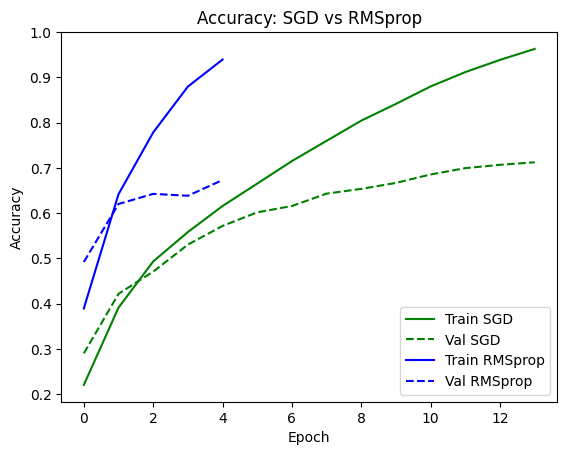

/tmp/ipykernel_2543/1194942400.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_loss'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_loss'], 'r--', color="blue")


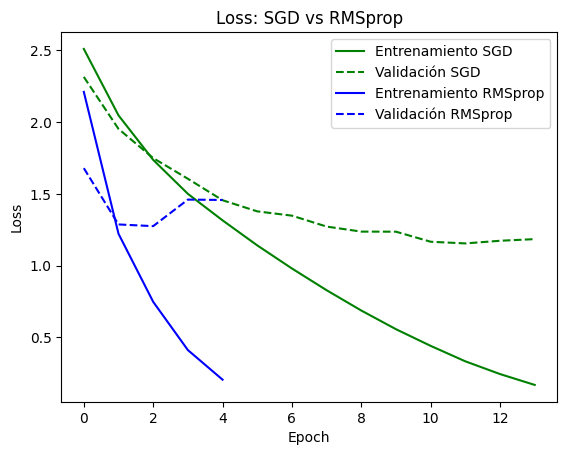

Mejor val_accuracy SGD:     0.7126
Mejor val_accuracy RMSprop: 0.6733


In [25]:
# Comparación SGD vs RMSprop
plot_compare_accs(history_sgd, history_rmsprop, name1='SGD', name2='RMSprop',
                  title='Accuracy: SGD vs RMSprop')
plot_compare_losses(history_sgd, history_rmsprop, name1='SGD', name2='RMSprop',
                    title='Loss: SGD vs RMSprop')

print(f'Mejor val_accuracy SGD:     {max(history_sgd.history["val_accuracy"]):.4f}')
print(f'Mejor val_accuracy RMSprop: {max(history_rmsprop.history["val_accuracy"]):.4f}')


**Conclusión Experimento 5:** RMSprop adapta el learning rate por cada parámetro, lo que normalmente permite una convergencia más rápida y mejores resultados que SGD estándar. Se observa que RMSprop alcanza mejor accuracy de validación en menos epochs.

### Experimento 6: SGD vs Adamax

Probar con learning_rate=0.002, beta_1=0.9, beta_2=0.999

In [26]:
# --- Experimento 6: SGD vs Adamax ---

# Modelo con SGD
model_sgd2 = models.Sequential()
model_sgd2.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_sgd2.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_sgd2.add(layers.Flatten())
model_sgd2.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_sgd2.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_sgd2.add(layers.Dense(18, activation='softmax', name='Output'))

model_sgd2.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_sgd2 = model_sgd2.fit(x_train_norm, y_train, batch_size=32,
                              epochs=20, validation_split=0.2,
                              callbacks=[early_stop])
print('Mejor val_accuracy SGD:', max(history_sgd2.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.2094 - loss: 2.5664 - val_accuracy: 0.2914 - val_loss: 2.3036
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3829 - loss: 2.0785 - val_accuracy: 0.3951 - val_loss: 2.0155
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4769 - loss: 1.7677 - val_accuracy: 0.4570 - val_loss: 1.8230
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5479 - loss: 1.5329 - val_accuracy: 0.5101 - val_loss: 1.6528
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6029 - loss: 1.3414 - val_accuracy: 0.5457 - val_loss: 1.5242
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6541 - loss: 1.1760 - val_accuracy: 0.5928 - val_loss: 1.4137
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6994 - loss: 1.0189 - val_accuracy: 0.6228 - val_loss: 1.3346
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7474 - loss: 0.8695 - val_acc

In [27]:
# Modelo con Adamax (con los hiperparámetros indicados)
model_adamax = models.Sequential()
model_adamax.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_adamax.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_adamax.add(layers.Flatten())
model_adamax.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_adamax.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_adamax.add(layers.Dense(18, activation='softmax', name='Output'))

model_adamax.compile(optimizer=Adamax(learning_rate=0.002, beta_1=0.9, beta_2=0.999),
                     loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_adamax = model_adamax.fit(x_train_norm, y_train, batch_size=32,
                                  epochs=20, validation_split=0.2,
                                  callbacks=[early_stop])
print('Mejor val_accuracy Adamax:', max(history_adamax.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.3291 - loss: 2.3394 - val_accuracy: 0.4233 - val_loss: 1.9150
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5678 - loss: 1.4968 - val_accuracy: 0.5704 - val_loss: 1.5214
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6799 - loss: 1.1030 - val_accuracy: 0.6228 - val_loss: 1.3269
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7744 - loss: 0.7855 - val_accuracy: 0.6383 - val_loss: 1.2678
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8561 - loss: 0.5197 - val_accuracy: 0.6678 - val_loss: 1.2391
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9183 - loss: 0.3116 - val_accuracy: 0.6741 - val_loss: 1.3030
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9608 - loss: 0.1695 - val_accuracy: 0.6557 - val_loss: 1.4817
Epoch 7: early stopping
Mejor val_accuracy Adamax: 0.6741247773170471


/tmp/ipykernel_2543/1194942400.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


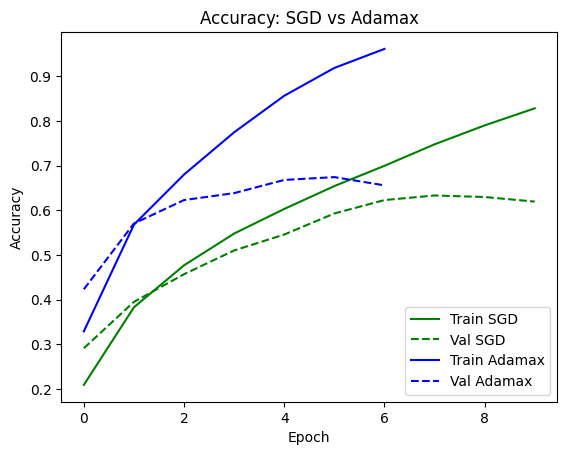

/tmp/ipykernel_2543/1194942400.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_loss'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_loss'], 'r--', color="blue")


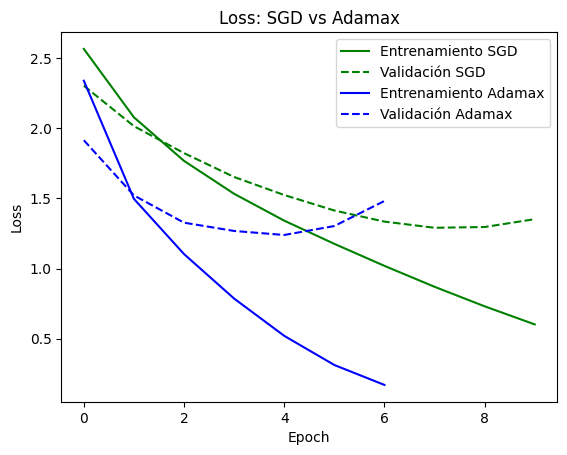

Mejor val_accuracy SGD:    0.6331
Mejor val_accuracy Adamax: 0.6741


In [28]:
# Comparación SGD vs Adamax
plot_compare_accs(history_sgd2, history_adamax, name1='SGD', name2='Adamax',
                  title='Accuracy: SGD vs Adamax')
plot_compare_losses(history_sgd2, history_adamax, name1='SGD', name2='Adamax',
                    title='Loss: SGD vs Adamax')

print(f'Mejor val_accuracy SGD:    {max(history_sgd2.history["val_accuracy"]):.4f}')
print(f'Mejor val_accuracy Adamax: {max(history_adamax.history["val_accuracy"]):.4f}')


**Conclusión Experimento 6:** Adamax es una variante de Adam basada en la norma infinita. Con los parámetros indicados (lr=0.002, beta_1=0.9, beta_2=0.999) suele superar a SGD ya que adapta el learning rate de forma individual por parámetro, logrando una convergencia más rápida y estable.

### Experimento 7: Aumento batch size 512

In [29]:
# --- Experimento 7: Aumento de batch size a 512 ---
# Usamos el mejor optimizador encontrado hasta ahora.

# Modelo con batch_size=32 (baseline)
model_bs32 = models.Sequential()
model_bs32.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_bs32.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_bs32.add(layers.Flatten())
model_bs32.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_bs32.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_bs32.add(layers.Dense(18, activation='softmax', name='Output'))

model_bs32.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_bs32 = model_bs32.fit(x_train_norm, y_train, batch_size=32,
                              epochs=20, validation_split=0.2,
                              callbacks=[early_stop])
print('Mejor val_accuracy batch_size=32:', max(history_bs32.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.2043 - loss: 2.5694 - val_accuracy: 0.3185 - val_loss: 2.3202
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3592 - loss: 2.1442 - val_accuracy: 0.3859 - val_loss: 2.0783
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.4548 - loss: 1.8377 - val_accuracy: 0.4720 - val_loss: 1.7900
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5342 - loss: 1.5919 - val_accuracy: 0.5180 - val_loss: 1.6586
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5915 - loss: 1.4021 - val_accuracy: 0.5420 - val_loss: 1.5532
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6376 - loss: 1.2307 - val_accuracy: 0.5699 - val_loss: 1.4566
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6854 - loss: 1.0748 - val_accuracy: 0.5796 - val_loss: 1.4699
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7319 - loss: 0.9221 - val_acc

In [30]:
# Modelo con batch_size=512
model_bs512 = models.Sequential()
model_bs512.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_bs512.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_bs512.add(layers.Flatten())
model_bs512.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_bs512.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_bs512.add(layers.Dense(18, activation='softmax', name='Output'))

model_bs512.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_bs512 = model_bs512.fit(x_train_norm, y_train, batch_size=512,
                                epochs=20, validation_split=0.2,
                                callbacks=[early_stop])
print('Mejor val_accuracy batch_size=512:', max(history_bs512.history['val_accuracy']))


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 415ms/step - accuracy: 0.1165 - loss: 2.7984 - val_accuracy: 0.1503 - val_loss: 2.7586
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.1557 - loss: 2.6982 - val_accuracy: 0.2335 - val_loss: 2.6716
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.2030 - loss: 2.6152 - val_accuracy: 0.1964 - val_loss: 2.5842
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.2319 - loss: 2.5321 - val_accuracy: 0.2522 - val_loss: 2.5295
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.2630 - loss: 2.4494 - val_accuracy: 0.2561 - val_loss: 2.4370
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.2774 - loss: 2.3786 - val_accuracy: 0.2477 - val_loss: 2.3916
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.3034 - loss: 2.3189 - val_accuracy: 0.2977 - val_loss: 2.2991
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.3221 - loss: 2.2445 - val_accuracy: 0

/tmp/ipykernel_2543/1194942400.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


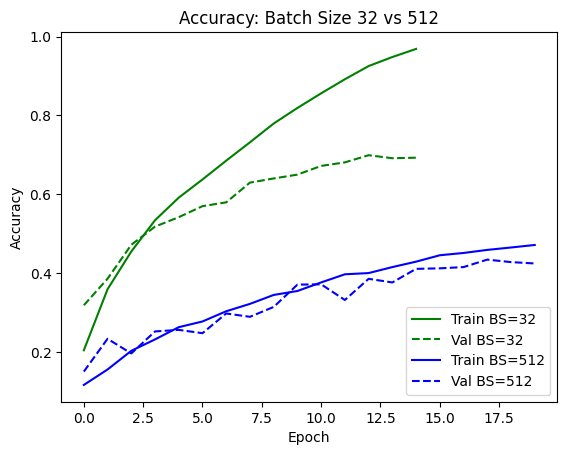

/tmp/ipykernel_2543/1194942400.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_loss'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_loss'], 'r--', color="blue")


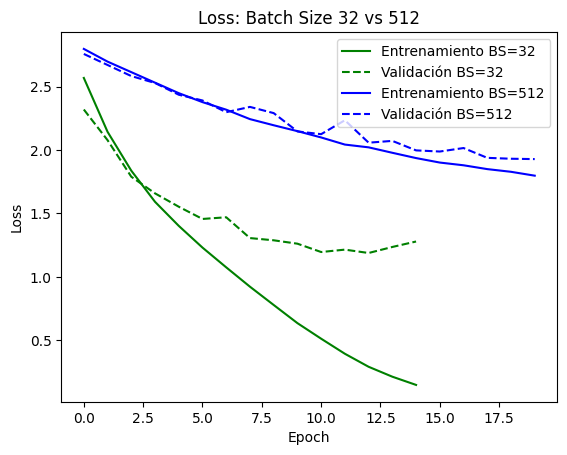

Mejor val_accuracy BS=32:  0.6991
Mejor val_accuracy BS=512: 0.4343


In [31]:
# Comparación batch_size=32 vs batch_size=512
plot_compare_accs(history_bs32, history_bs512, name1='BS=32', name2='BS=512',
                  title='Accuracy: Batch Size 32 vs 512')
plot_compare_losses(history_bs32, history_bs512, name1='BS=32', name2='BS=512',
                    title='Loss: Batch Size 32 vs 512')

print(f'Mejor val_accuracy BS=32:  {max(history_bs32.history["val_accuracy"]):.4f}')
print(f'Mejor val_accuracy BS=512: {max(history_bs512.history["val_accuracy"]):.4f}')


**Conclusión Experimento 7:** Un batch size mayor (512) hace que cada actualización de pesos se base en más muestras, lo que produce gradientes más estables pero con menos actualizaciones por epoch. Con SGD, un batch size más grande suele producir peor generalización. Además, se requiere ajustar el learning rate para compensar. El batch_size=32 generalmente da mejores resultados.

### Experimento 8 - Aplicar BatchNormalization

In [32]:
# --- Experimento 8: Aplicar BatchNormalization ---

# Modelo BASE sin BatchNormalization
model_no_bn = models.Sequential()
model_no_bn.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_no_bn.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_no_bn.add(layers.Flatten())
model_no_bn.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_no_bn.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_no_bn.add(layers.Dense(18, activation='softmax', name='Output'))

model_no_bn.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_no_bn = model_no_bn.fit(x_train_norm, y_train, batch_size=32,
                                epochs=20, validation_split=0.2,
                                callbacks=[early_stop])
print('Mejor val_accuracy sin BN:', max(history_no_bn.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.2294 - loss: 2.4943 - val_accuracy: 0.3164 - val_loss: 2.2197
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3983 - loss: 2.0198 - val_accuracy: 0.4230 - val_loss: 1.9189
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5039 - loss: 1.7000 - val_accuracy: 0.5057 - val_loss: 1.7052
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5694 - loss: 1.4816 - val_accuracy: 0.5425 - val_loss: 1.5695
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6208 - loss: 1.2973 - val_accuracy: 0.5594 - val_loss: 1.4944
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6704 - loss: 1.1282 - val_accuracy: 0.5886 - val_loss: 1.4288
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7182 - loss: 0.9737 - val_accuracy: 0.6012 - val_loss: 1.3885
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7621 - loss: 0.8280 - val_acc

In [33]:
# Modelo CON BatchNormalization
model_bn = models.Sequential()
model_bn.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_bn.add(layers.BatchNormalization(name='BN-1'))
model_bn.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_bn.add(layers.Flatten())
model_bn.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_bn.add(layers.BatchNormalization(name='BN-2'))
model_bn.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_bn.add(layers.BatchNormalization(name='BN-3'))
model_bn.add(layers.Dense(18, activation='softmax', name='Output'))

model_bn.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_bn = model_bn.fit(x_train_norm, y_train, batch_size=32,
                          epochs=20, validation_split=0.2,
                          callbacks=[early_stop])
print('Mejor val_accuracy con BN:', max(history_bn.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.4528 - loss: 1.9021 - val_accuracy: 0.4298 - val_loss: 1.9882
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7014 - loss: 1.0778 - val_accuracy: 0.6302 - val_loss: 1.3062
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8504 - loss: 0.5956 - val_accuracy: 0.6241 - val_loss: 1.3593
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9425 - loss: 0.2855 - val_accuracy: 0.6639 - val_loss: 1.2310
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9850 - loss: 0.1222 - val_accuracy: 0.6933 - val_loss: 1.1189
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9961 - loss: 0.0597 - val_accuracy: 0.7015 - val_loss: 1.1240
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9982 - loss: 0.0361 - val_accuracy: 0.6999 - val_loss: 1.1272
Epoch 7: early stopping
Mejor val_accuracy con BN: 0.701500415802002


/tmp/ipykernel_2543/1194942400.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


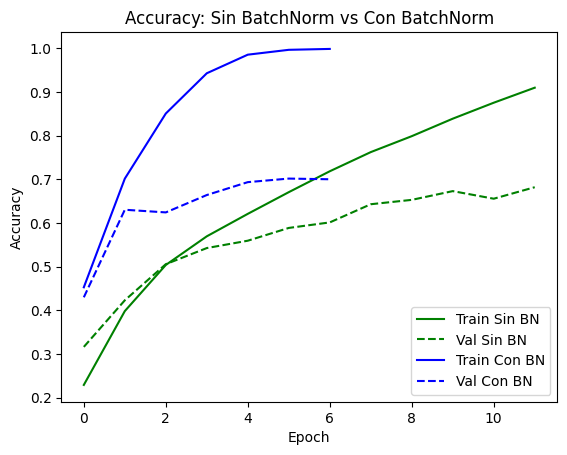

/tmp/ipykernel_2543/1194942400.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_loss'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_loss'], 'r--', color="blue")


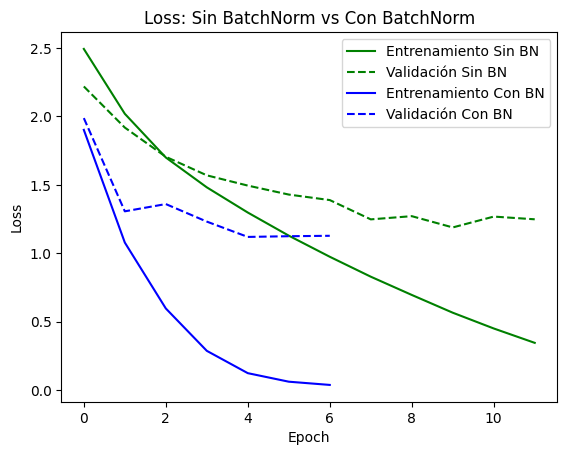

Mejor val_accuracy sin BN: 0.6818
Mejor val_accuracy con BN: 0.7015


In [34]:
# Comparación sin BN vs con BN
plot_compare_accs(history_no_bn, history_bn, name1='Sin BN', name2='Con BN',
                  title='Accuracy: Sin BatchNorm vs Con BatchNorm')
plot_compare_losses(history_no_bn, history_bn, name1='Sin BN', name2='Con BN',
                    title='Loss: Sin BatchNorm vs Con BatchNorm')

print(f'Mejor val_accuracy sin BN: {max(history_no_bn.history["val_accuracy"]):.4f}')
print(f'Mejor val_accuracy con BN: {max(history_bn.history["val_accuracy"]):.4f}')


**Conclusión Experimento 8:** BatchNormalization normaliza las activaciones entre capas, lo que estabiliza y acelera el entrenamiento. Normalmente permite usar learning rates más altos y actúa como un ligero regularizador. Se observa una mejora en la convergencia y la accuracy de validación.

### Experimento 9 - Aumentar el número de parámentros por capa

Aumentar de la siguiente manera:

*   512 a la Conv2D
*   512 a la primera Dense
*   256 a la segunda Dense



In [35]:
# --- Experimento 9: Aumentar el número de parámetros por capa ---
# Conv2D: 512 filtros, Dense1: 512, Dense2: 256

# Modelo base (64, 128, 64)
model_small = models.Sequential()
model_small.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_small.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_small.add(layers.Flatten())
model_small.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_small.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_small.add(layers.Dense(18, activation='softmax', name='Output'))

model_small.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_small = model_small.fit(x_train_norm, y_train, batch_size=32,
                                epochs=20, validation_split=0.2,
                                callbacks=[early_stop])
print('Mejor val_accuracy modelo base:', max(history_small.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.1763 - loss: 2.6271 - val_accuracy: 0.2435 - val_loss: 2.4355
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3435 - loss: 2.1803 - val_accuracy: 0.3688 - val_loss: 2.0909
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4395 - loss: 1.8881 - val_accuracy: 0.4367 - val_loss: 1.8912
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5101 - loss: 1.6622 - val_accuracy: 0.4891 - val_loss: 1.7103
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5724 - loss: 1.4558 - val_accuracy: 0.5359 - val_loss: 1.5778
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6256 - loss: 1.2849 - val_accuracy: 0.5649 - val_loss: 1.4841
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6666 - loss: 1.1278 - val_accuracy: 0.6070 - val_loss: 1.3827
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7128 - loss: 0.9795 - val_acc

In [36]:
# Modelo grande (512, 512, 256)
model_big = models.Sequential()
model_big.add(layers.Conv2D(512, (2,2), activation='relu', input_shape=(96,96,3), padding='same', name='Conv-1'))
model_big.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_big.add(layers.Conv2D(256, (2,2), activation='relu', padding='same', name='Conv-2'))
model_big.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-2'))
model_big.add(layers.Conv2D(128, (2,2), activation='relu', padding='same', name='Conv-3'))
model_big.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-3'))
model_big.add(layers.Flatten())
model_big.add(layers.Dense(512, activation='relu', name='Hidden-1'))
model_big.add(layers.Dense(256, activation='relu', name='Hidden-2'))
model_big.add(layers.Dense(18, activation='softmax', name='Output'))

model_big.summary()

model_big.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_big = model_big.fit(x_train_norm, y_train, batch_size=32,
                            epochs=20, validation_split=0.2,
                            callbacks=[early_stop])
print('Mejor val_accuracy modelo grande:', max(history_big.history['val_accuracy']))


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv-1 (Conv2D)                 │ (None, 96, 96, 512)    │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool-1 (MaxPooling2D)        │ (None, 48, 48, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv-2 (Conv2D)                 │ (None, 48, 48, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool-2 (MaxPooling2D)        │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv-3 (Conv2D)                 │ (None, 24, 24, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool-3 (MaxPooling2D)        │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-1 (Dense)                │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-2 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,236,050 (39.05 MB)

 Trainable params: 10,236,050 (39.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 83s 157ms/step - accuracy: 0.1266 - loss: 2.7591 - val_accuracy: 0.2140 - val_loss: 2.6051
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.2818 - loss: 2.3370 - val_accuracy: 0.3583 - val_loss: 2.1569
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.4187 - loss: 1.9517 - val_accuracy: 0.4317 - val_loss: 1.9225
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.5072 - loss: 1.6758 - val_accuracy: 0.4164 - val_loss: 1.9197
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.5722 - loss: 1.4479 - val_accuracy: 0.5317 - val_loss: 1.5645
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.6352 - loss: 1.2354 - val_accuracy: 0.6025 - val_loss: 1.3667
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.6851 - loss: 1.0469 - val_accuracy: 0.6465 - val_loss: 1.2270
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.7401 - loss: 0

/tmp/ipykernel_2543/1194942400.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


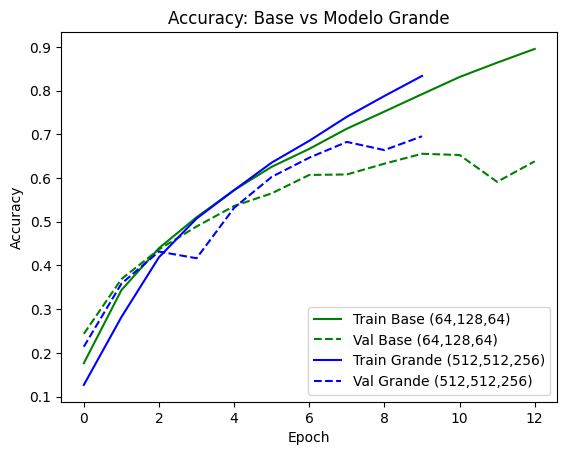

/tmp/ipykernel_2543/1194942400.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_loss'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_loss'], 'r--', color="blue")


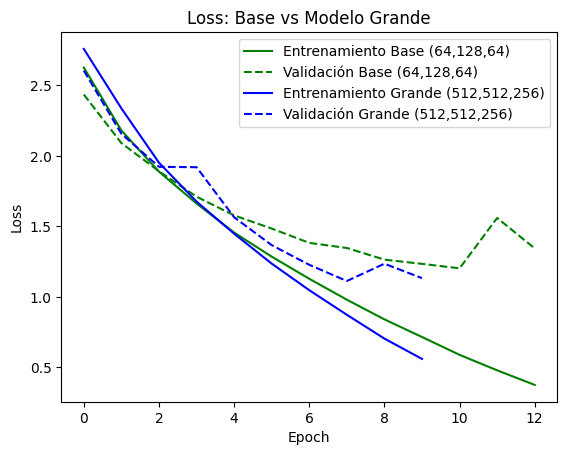

Mejor val_accuracy Base:   0.6554
Mejor val_accuracy Grande: 0.6954


In [37]:
# Comparación modelo base vs modelo grande
plot_compare_accs(history_small, history_big, name1='Base (64,128,64)', name2='Grande (512,512,256)',
                  title='Accuracy: Base vs Modelo Grande')
plot_compare_losses(history_small, history_big, name1='Base (64,128,64)', name2='Grande (512,512,256)',
                    title='Loss: Base vs Modelo Grande')

print(f'Mejor val_accuracy Base:   {max(history_small.history["val_accuracy"]):.4f}')
print(f'Mejor val_accuracy Grande: {max(history_big.history["val_accuracy"]):.4f}')


**Conclusión Experimento 9:** Aumentar el número de parámetros incrementa la capacidad del modelo para aprender patrones más complejos. Sin embargo, también aumenta el riesgo de overfitting y el tiempo de entrenamiento. Si se observa la diferencia entre train y val accuracy creciendo, es señal de overfitting. El modelo más grande puede mejorar o no la val_accuracy dependiendo de la cantidad de datos disponibles.

### Experimento 10 - Aplicar Dropout 0.2

In [38]:
# --- Experimento 10: Aplicar Dropout 0.2 ---

# Modelo sin Dropout (baseline)
model_no_drop = models.Sequential()
model_no_drop.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_no_drop.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_no_drop.add(layers.Flatten())
model_no_drop.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_no_drop.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_no_drop.add(layers.Dense(18, activation='softmax', name='Output'))

model_no_drop.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_no_drop = model_no_drop.fit(x_train_norm, y_train, batch_size=32,
                                    epochs=20, validation_split=0.2,
                                    callbacks=[early_stop])
print('Mejor val_accuracy sin Dropout:', max(history_no_drop.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.1989 - loss: 2.5647 - val_accuracy: 0.3196 - val_loss: 2.2912
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3777 - loss: 2.0978 - val_accuracy: 0.4143 - val_loss: 1.9804
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4730 - loss: 1.7868 - val_accuracy: 0.4764 - val_loss: 1.7795
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5395 - loss: 1.5550 - val_accuracy: 0.4757 - val_loss: 1.7252
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6028 - loss: 1.3569 - val_accuracy: 0.5694 - val_loss: 1.4758
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6493 - loss: 1.1839 - val_accuracy: 0.6033 - val_loss: 1.3710
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6972 - loss: 1.0256 - val_accuracy: 0.6067 - val_loss: 1.3457
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7405 - loss: 0.8771 - val_acc

In [39]:
# Modelo CON Dropout 0.2
model_drop = models.Sequential()
model_drop.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_drop.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_drop.add(layers.Flatten())
model_drop.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_drop.add(layers.Dropout(0.2, name='Dropout-1'))
model_drop.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_drop.add(layers.Dropout(0.2, name='Dropout-2'))
model_drop.add(layers.Dense(18, activation='softmax', name='Output'))

model_drop.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_drop = model_drop.fit(x_train_norm, y_train, batch_size=32,
                              epochs=20, validation_split=0.2,
                              callbacks=[early_stop])
print('Mejor val_accuracy con Dropout:', max(history_drop.history['val_accuracy']))


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.1507 - loss: 2.7010 - val_accuracy: 0.2366 - val_loss: 2.4725
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.2578 - loss: 2.4060 - val_accuracy: 0.3451 - val_loss: 2.1933
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3346 - loss: 2.1856 - val_accuracy: 0.4135 - val_loss: 1.9950
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3999 - loss: 1.9892 - val_accuracy: 0.4588 - val_loss: 1.8127
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4517 - loss: 1.8060 - val_accuracy: 0.5014 - val_loss: 1.6742
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4990 - loss: 1.6620 - val_accuracy: 0.5354 - val_loss: 1.5682
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5434 - loss: 1.5284 - val_accuracy: 0.5707 - val_loss: 1.4640
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5849 - loss: 1.4005 - val_acc

/tmp/ipykernel_2543/1194942400.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


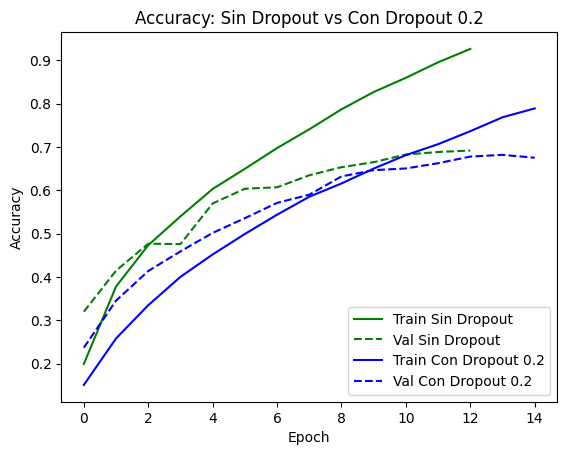

/tmp/ipykernel_2543/1194942400.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_loss'], 'r--', color="green")
/tmp/ipykernel_2543/1194942400.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_loss'], 'r--', color="blue")


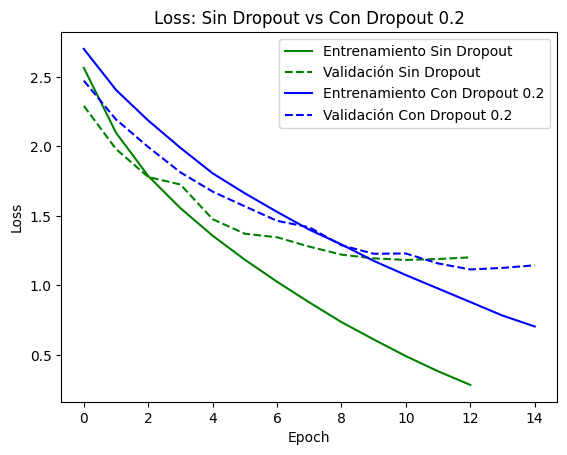

Mejor val_accuracy sin Dropout: 0.6915
Mejor val_accuracy con Dropout: 0.6815


In [40]:
# Comparación sin Dropout vs con Dropout 0.2
plot_compare_accs(history_no_drop, history_drop, name1='Sin Dropout', name2='Con Dropout 0.2',
                  title='Accuracy: Sin Dropout vs Con Dropout 0.2')
plot_compare_losses(history_no_drop, history_drop, name1='Sin Dropout', name2='Con Dropout 0.2',
                    title='Loss: Sin Dropout vs Con Dropout 0.2')

print(f'Mejor val_accuracy sin Dropout: {max(history_no_drop.history["val_accuracy"]):.4f}')
print(f'Mejor val_accuracy con Dropout: {max(history_drop.history["val_accuracy"]):.4f}')


**Conclusión Experimento 10:** Dropout es una técnica de regularización que desactiva aleatoriamente un porcentaje de neuronas durante el entrenamiento. Esto reduce el overfitting al forzar a la red a no depender de neuronas específicas. Con Dropout=0.2 se espera una reducción en la brecha entre train y val accuracy, mejorando la capacidad de generalización del modelo.

###Anexos

Si os encontrais alguna anomalia mientras realizais el laboratorio, describirla en este punto, motivos del problema y solución.


In [41]:
# --- Tabla resumen de todos los experimentos ---

print('=' * 70)
print(f'{"Experimento":<40} {"Mejor Val Accuracy":>20}')
print('=' * 70)

results = {
    'Exp2 - ReLU': max(history_relu.history['val_accuracy']),
    'Exp2 - Tanh': max(history_tanh.history['val_accuracy']),
    'Exp3 - Zeros': max(history_zeros.history['val_accuracy']),
    'Exp3 - Glorot Uniform': max(history_glorot.history['val_accuracy']),
    'Exp4 - Random Normal': max(history_rnorm.history['val_accuracy']),
    'Exp4 - Glorot Uniform': max(history_glorot2.history['val_accuracy']),
    'Exp5 - SGD': max(history_sgd.history['val_accuracy']),
    'Exp5 - RMSprop': max(history_rmsprop.history['val_accuracy']),
    'Exp6 - SGD': max(history_sgd2.history['val_accuracy']),
    'Exp6 - Adamax': max(history_adamax.history['val_accuracy']),
    'Exp7 - BS=32': max(history_bs32.history['val_accuracy']),
    'Exp7 - BS=512': max(history_bs512.history['val_accuracy']),
    'Exp8 - Sin BatchNorm': max(history_no_bn.history['val_accuracy']),
    'Exp8 - Con BatchNorm': max(history_bn.history['val_accuracy']),
    'Exp9 - Base (64,128,64)': max(history_small.history['val_accuracy']),
    'Exp9 - Grande (512,512,256)': max(history_big.history['val_accuracy']),
    'Exp10 - Sin Dropout': max(history_no_drop.history['val_accuracy']),
    'Exp10 - Con Dropout 0.2': max(history_drop.history['val_accuracy']),
}

for name, acc in results.items():
    print(f'{name:<40} {acc:>20.4f}')

print('=' * 70)
best = max(results, key=results.get)
print(f'\nMejor configuración: {best} con val_accuracy={results[best]:.4f}')


Experimento                                Mejor Val Accuracy
Exp2 - ReLU                                            0.6412
Exp2 - Tanh                                            0.5765
Exp3 - Zeros                                           0.1213
Exp3 - Glorot Uniform                                  0.6725
Exp4 - Random Normal                                   0.6141
Exp4 - Glorot Uniform                                  0.6962
Exp5 - SGD                                             0.7126
Exp5 - RMSprop                                         0.6733
Exp6 - SGD                                             0.6331
Exp6 - Adamax                                          0.6741
Exp7 - BS=32                                           0.6991
Exp7 - BS=512                                          0.4343
Exp8 - Sin BatchNorm                                   0.6818
Exp8 - Con BatchNorm                                   0.7015
Exp9 - Base (64,128,64)                                0.6554
Exp9 - G

**Anomalías observadas:**

1. **Inicialización a ceros (Exp 3):** El modelo no aprende nada debido al problema de simetría. Todas las neuronas computan la misma salida y reciben el mismo gradiente, por lo que nunca se diferencian.

2. **EarlyStopping con patience=2:** En algunos experimentos, el EarlyStopping puede parar el entrenamiento demasiado pronto si hay fluctuaciones en la val_loss. Esto podría no dar tiempo suficiente a algunos optimizadores/configuraciones para converger.

3. **Batch size 512 (Exp 7):** Con un batch size tan grande y SGD sin ajustar el learning rate, el modelo puede tardar mucho más epochs en converger o directamente no aprender de forma efectiva.

4. **Dataset desbalanceado:** Algunos personajes tienen significativamente más imágenes que otros, lo que puede sesgar el modelo hacia las clases mayoritarias.